# RestAPIs

In [1]:
import requests  #!pip install requests

# --> goal: make HTTP requests simpler and more human-friendly

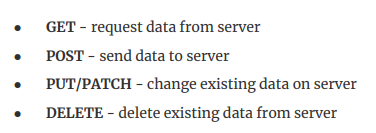

In [17]:
# GET
api_url = "https://jsonplaceholder.typicode.com/todos"
response = requests.get(api_url)
response.json()

[{'userId': 1, 'id': 1, 'title': 'delectus aut autem', 'completed': False},
 {'userId': 1,
  'id': 2,
  'title': 'quis ut nam facilis et officia qui',
  'completed': False},
 {'userId': 1, 'id': 3, 'title': 'fugiat veniam minus', 'completed': False},
 {'userId': 1, 'id': 4, 'title': 'et porro tempora', 'completed': True},
 {'userId': 1,
  'id': 5,
  'title': 'laboriosam mollitia et enim quasi adipisci quia provident illum',
  'completed': False},
 {'userId': 1,
  'id': 6,
  'title': 'qui ullam ratione quibusdam voluptatem quia omnis',
  'completed': False},
 {'userId': 1,
  'id': 7,
  'title': 'illo expedita consequatur quia in',
  'completed': False},
 {'userId': 1,
  'id': 8,
  'title': 'quo adipisci enim quam ut ab',
  'completed': True},
 {'userId': 1,
  'id': 9,
  'title': 'molestiae perspiciatis ipsa',
  'completed': False},
 {'userId': 1,
  'id': 10,
  'title': 'illo est ratione doloremque quia maiores aut',
  'completed': True},
 {'userId': 1,
  'id': 11,
  'title': 'vero rerum

In [19]:
# POST
todo = {
    "userId": 1,
    "title": "Do DSSS homework",
    "completed": False
}

api_url = "https://jsonplaceholder.typicode.com/todos"
response = requests.post(api_url, json=todo)
response.json()

{'userId': 1, 'title': 'Do DSSS homework', 'completed': False, 'id': 201}

In [21]:
# PUT (-->  completely replacing the existing resource)
api_url = "https://jsonplaceholder.typicode.com/todos/194"
response = requests.get(api_url)
print(response.json())

todo['completed'] = True

response = requests.put(api_url, json=todo)
response.json()

{'userId': 10, 'id': 194, 'title': 'sed ut vero sit molestiae', 'completed': False}


{'userId': 1, 'title': 'Do DSSS homework', 'completed': True, 'id': 194}

In [26]:
# PATCH (--> only modifies the values set in the JSON sent with the request)
api_url = "https://jsonplaceholder.typicode.com/todos/13"
todo = {"title": "Learn for the DSSS exam"}
response = requests.patch(api_url, json=todo)
response.json()

{'userId': 1, 'id': 13, 'title': 'Learn for the DSSS exam', 'completed': False}

In [28]:
api_url = "https://jsonplaceholder.typicode.com/todos/10"
response = requests.delete(api_url)
response.json()

{}

## Flickr API

In [29]:
from  flickrapi import FlickrAPI  # !pip install flickrapi

https://www.flickr.com/services/apps/create/

In [30]:
key = ""
secret = ""

In [149]:
flickr = FlickrAPI(key, secret, format='parsed-json')

In [34]:
def get_brands(flickr):
    return flickr.cameras.getBrands()['brands']['brand']

In [37]:
cam_brands = get_brands(flickr)

print('\nTotal number of brands:', len(cam_brands))
print('\nBrands:', [cam_brand['name'] for cam_brand in cam_brands])


Total number of brands: 48

Brands: ['Apple', 'Canon', 'Nikon', 'Sony', 'Fujifilm', 'Panasonic', 'Olympus', 'Samsung', 'Google', 'Ricoh', 'Leica', 'Huawei', 'DJI', 'Xiaomi', 'Pentax', 'OnePlus', 'Hasselblad', 'Kodak', 'GoPro', 'Sigma', 'Konica Minolta', 'Nokia', 'Phase One', 'Motorola', 'Casio', 'Sony Ericsson', 'LG', 'HP', 'HTC', 'BlackBerry', 'Concord', 'BenQ', 'Epson', 'Toshiba', 'Mamiya', 'Nintendo', 'Leaf', 'Helio', 'Palm', 'Sharp', 'Polaroid', 'KDDI', 'JVC', 'DoCoMo', 'Acer', 'Kyocera', 'Vivitar', 'Sanyo']


In [43]:
def get_cam_models(cam_brands):
    models = []
    for i in range(len(cam_brands)): #
        try:
            cameras = flickr.cameras.getBrandModels(brand = cam_brands[i]['name'])['cameras']
            models.append(cameras)
        except:
            pass  
    return models

In [44]:
cam_models = get_cam_models(cam_brands)

print('\nAmount of brands saved: ', len(cam_models)) 

print('\nModels known by Flickr: ', cam_models)

print("\nThe brand '{0}' has {1} cameras registered.".format(cam_models[0]['brand'], len(cam_models[0]['camera'])))


Amount of brands saved:  45

Models known by Flickr:  [{'brand': 'apple', 'camera': [{'id': 'iphone_11', 'name': {'_content': 'Apple iPhone 11'}, 'images': {'small': {'_content': 'https://live.staticflickr.com/cameras/72157710863218722_model_small_0dea2238da.jpg'}, 'large': {'_content': 'https://live.staticflickr.com/cameras/72157710863218722_model_large_7a060247cc.jpg'}}}, {'id': 'iphone_13_pro', 'name': {'_content': 'Apple iPhone 13 Pro'}, 'images': {'small': {'_content': 'https://live.staticflickr.com/cameras/72157720412160168_model_small_75c14ed7ab.jpg'}, 'large': {'_content': 'https://live.staticflickr.com/cameras/72157720412160168_model_large_312494f578.jpg'}}}, {'id': 'iphone_13_pro_max', 'name': {'_content': 'Apple iPhone 13 Pro Max'}, 'images': {'small': {'_content': 'https://live.staticflickr.com/cameras/72157720419252901_model_small_06cf1a3d69.jpg'}, 'large': {'_content': 'https://live.staticflickr.com/cameras/72157720419252901_model_large_6793010a07.jpg'}}}, {'id': 'iphone

### https://www.flickr.com/services/api/flickr.photos.search.html

In [168]:
def get_photos(flickr, num=100):  
    result  = flickr.photos.search(
        text = 'ant', 
        per_page = num, # Default 100, maximum allowed: 500.
        media = 'photos', # all (default), photos or videos
        content_type = 1, #just photos (no screenshots nor 'other')
        sort = 'relevance', 
        privacy_filter = 1, #public photos
        safe_search = 1
    )
    return result

In [169]:
result = get_photos(flickr, num = 10)
result['photos']['photo'][0]

{'id': '14058217107',
 'owner': '114017326@N05',
 'secret': '01c59da497',
 'server': '5489',
 'farm': 6,
 'title': 'Ant',
 'ispublic': 1,
 'isfriend': 0,
 'isfamily': 0}

#### How to get the images?  --> https://www.flickr.com/services/api/misc.urls.html
#### `https://live.staticflickr.com/{server-id}/{id}_{secret}_{size-suffix}.jpg`

In [170]:
photo = result['photos']['photo'][0]
url = f"https://live.staticflickr.com/{photo['server']}/{photo['id']}_{photo['secret']}.jpg"
url

'https://live.staticflickr.com/5489/14058217107_01c59da497.jpg'

### Alternative: request 'url-c' directly --> extras='url-c'

In [164]:
def get_photos(flickr, num=100):  
    result  = flickr.photos.search(
        text = 'ant', 
        per_page = num, # Default 100, maximum allowed: 500.
        media = 'photos', # all (default), photos or videos
        content_type = 1, #just photos (no screenshots nor 'other')
        sort = 'relevance', 
        privacy_filter = 1, #public photos
        safe_search = 1,
        extras='url_c'
    )
    return result

In [165]:
result = get_photos(flickr, num = 10)
result['photos']['photo'][0]

{'id': '3409453035',
 'owner': '30867687@N08',
 'secret': 'c4d2940b89',
 'server': '3040',
 'farm': 4,
 'title': 'Ant',
 'ispublic': 1,
 'isfriend': 0,
 'isfamily': 0,
 'url_c': 'https://live.staticflickr.com/3040/3409453035_c4d2940b89_c.jpg',
 'height_c': 567,
 'width_c': 800}

In [166]:
url_c = photo = result['photos']['photo'][0]['url_c']
url_c

'https://live.staticflickr.com/3040/3409453035_c4d2940b89_c.jpg'

### https://www.w3schools.com/python/ref_requests_get.asp

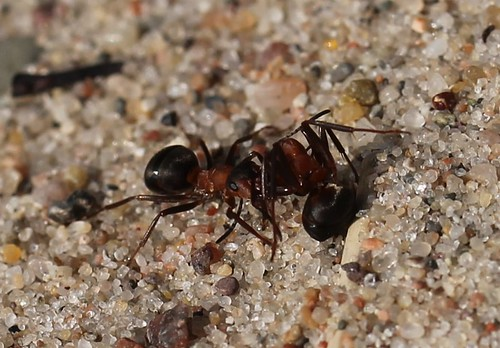

In [173]:
response = requests.get(url, stream=True) 
Image.open(response.raw)

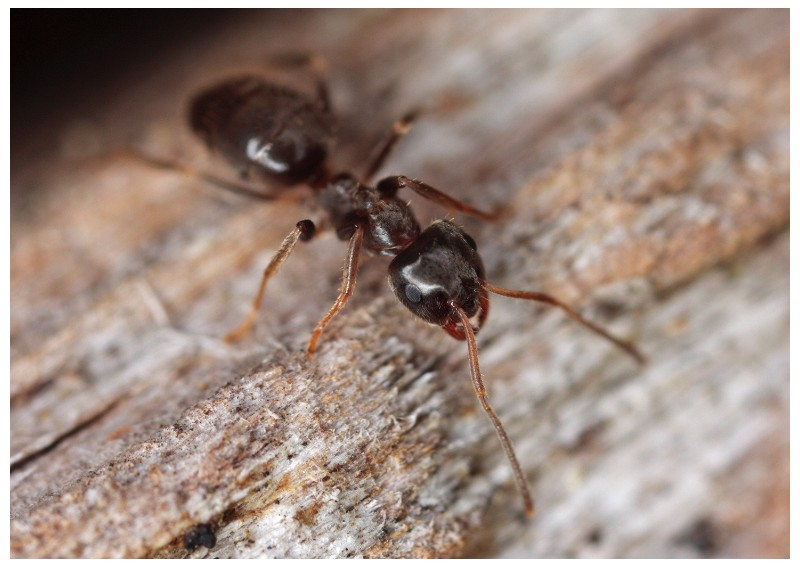

In [175]:
response = requests.get(url_c, stream=True) 
Image.open(response.raw)

In [176]:
from PIL import Image
from io import BytesIO

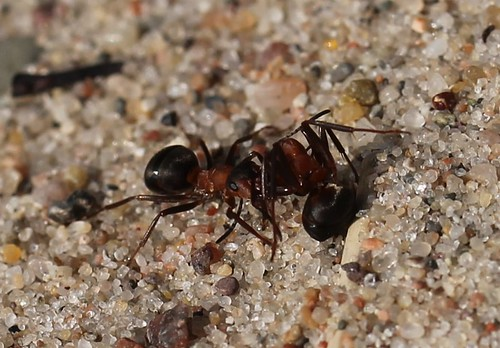

In [177]:
response = requests.get(url)
Image.open(BytesIO(response.content))

### Another way
#### Use flickr.walk to get a Generator (takes the same arguments as flickr.photos.search)

In [181]:
flickr = FlickrAPI(key, secret, format='etree')

In [182]:
keyword = "apple"
photos = flickr.walk(text=keyword,
                     tag_mode='all',
                     tags=keyword,
                     extras='url_c',
                     per_page=100,
                     sort='relevance')

In [209]:
urls = []
for i, photo in enumerate(photos):
    urls.append(photo.get('url_c'))
    
    if i == 3:
        break

In [210]:
urls

['https://live.staticflickr.com/6210/6088899104_4671ecb8c7_c.jpg',
 'https://live.staticflickr.com/6145/5951079854_268766c8e8_c.jpg',
 'https://live.staticflickr.com/3135/2906849739_b942c783f7_c.jpg',
 'https://live.staticflickr.com/6063/6088356389_3a539644de_c.jpg']

In [187]:
import urllib.request

In [211]:
for i in range(4):
    urllib.request.urlretrieve(urls[i], keyword + f'_{i}.jpg')

In [212]:
import os
os.listdir(".")

['.ipynb_checkpoints',
 'apple_0.jpg',
 'apple_1.jpg',
 'apple_2.jpg',
 'apple_3.jpg',
 'Exercise_9_solution.ipynb']

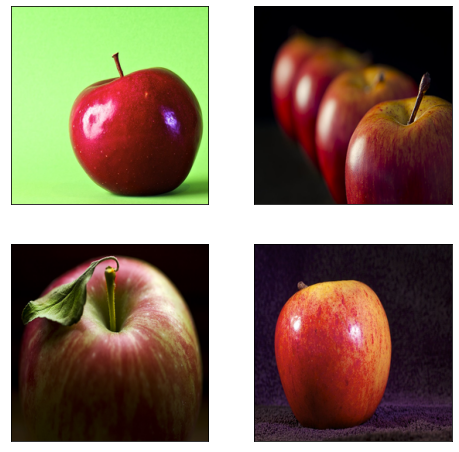

In [224]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, 2, figsize=(8, 8))

for i in range(2):
    for j in range(2):
        image = Image.open(keyword + f'_{2*i + j}.jpg') 
        image = image.resize((256, 256), Image.ANTIALIAS)
    
        ax[i, j].imshow(image)
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])

# Telegram Bot
https://learn.microsoft.com/en-us/azure/bot-service/bot-service-channel-connect-telegram?view=azure-bot-service-4.0

In [237]:
personal_token = ''

In [247]:
ping_url = 'https://api.telegram.org/bot'+str(personal_token)+'/getUpdates'
response = requests.get(ping_url).json()
response

{'ok': True,
 'result': [{'update_id': 976668075,
   'message': {'message_id': 8,
    'from': {'id': 1781218024,
     'is_bot': False,
     'first_name': 'René',
     'language_code': 'de'},
    'chat': {'id': 1781218024, 'first_name': 'René', 'type': 'private'},
    'date': 1673548084,
    'text': 'Test'}},
  {'update_id': 976668076,
   'message': {'message_id': 9,
    'from': {'id': 1781218024,
     'is_bot': False,
     'first_name': 'René',
     'language_code': 'de'},
    'chat': {'id': 1781218024, 'first_name': 'René', 'type': 'private'},
    'date': 1673548326,
    'text': 'Test'}},
  {'update_id': 976668077,
   'message': {'message_id': 10,
    'from': {'id': 1781218024,
     'is_bot': False,
     'first_name': 'René',
     'language_code': 'de'},
    'chat': {'id': 1781218024, 'first_name': 'René', 'type': 'private'},
    'date': 1673603109,
    'text': 'Test'}}]}

In [244]:
chat_id = response['result'][0]['message']['chat']['id']

In [248]:
ping_url = 'https://api.telegram.org/bot'+str(personal_token)+'/sendMessage?'+\
                    'chat_id='+str(chat_id)+\
                    '&parse_mode=Markdown'+\
                    '&text='+ 'test'
response = requests.get(ping_url)
ping_url

'https://api.telegram.org/bot5865415800:AAGuBHpewq5UmSJdH0iSFU2QgecG7DRsJvQ/sendMessage?chat_id=1781218024&parse_mode=Markdown&text=Hallo Isi'

In [ ]:
last_message_id = response['result'][-1]["message"]["message_id"]

# Additional information for homework 9

In [ ]:
class BotCallback(tf.keras.callbacks.Callback):
    def __init__(self,personal_token):
        self.personal_token = personal_token
        self.ping_url = 'https://api.telegram.org/bot'+str(self.personal_token)+'/getUpdates'
        self.response = requests.get(self.ping_url).json()
        self.chat_id = self.response['result'][0]['message']['chat']['id']

    def send_message(self,message):
        self.ping_url = 'https://api.telegram.org/bot'+str(self.personal_token)+'/sendMessage?'+\
                        'chat_id='+str(self.chat_id)+\
                        '&parse_mode=Markdown'+\
                        '&text='+message
        self.response = requests.get(self.ping_url)

    def on_epoch_end(self, epoch, epoch_logs):
        # TODO
        pass